In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [ ]:
import pandas as pd

path = "social_media_comments.csv"

encodings_to_try = ["utf-8", "utf-8-sig", "cp1254", "latin1", "ISO-8859-9", "utf-16"]

last_err = None
for enc in encodings_to_try:
    try:
        df = pd.read_csv(path, encoding=enc)
        print(f"✅ Loaded successfully with encoding: {enc}")
        print("Shape:", df.shape)
        print("Columns:", list(df.columns))
        display(df.head())
        break
    except Exception as e:
        last_err = e
        print(f"❌ Failed with {enc}: {type(e).__name__}")
else:
    print("\nAll encodings failed. Last error:\n", last_err)

❌ Failed with utf-8: UnicodeDecodeError
❌ Failed with utf-8-sig: UnicodeDecodeError
✅ Loaded successfully with encoding: cp1254
Shape: (11119, 2)
Columns: ['Tip', 'Paylaşım']


,Tip,Paylaşım
0,Negatif,doğa ağzımıza sıçsa hakkı var
1,Pozitif,anne bir sanatçıdır güzel eseri yavrusudur
2,Negatif,ibrahimin oğlunu koruyan tanrı ben sokayım
3,Negatif,köpeğim suratına sıçsın senin namussuz karı
4,Negatif,ben söğüşledim birazda sen söğüşle


In [ ]:
import pandas as pd

df = pd.read_csv("social_media_comments.csv", encoding="cp1254")

# Kolonları netleştirme
df = df[["Paylaşım", "Tip"]].dropna()

# İsimleri standartlaştırma
df.rename(columns={
    "Paylaşım": "text",
    "Tip": "label"
}, inplace=True)

df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(str)

print(df.shape)
display(df.head())

(11117, 2)


,text,label
0,doğa ağzımıza sıçsa hakkı var,Negatif
1,anne bir sanatçıdır güzel eseri yavrusudur,Pozitif
2,ibrahimin oğlunu koruyan tanrı ben sokayım,Negatif
3,köpeğim suratına sıçsın senin namussuz karı,Negatif
4,ben söğüşledim birazda sen söğüşle,Negatif


In [ ]:
print(df["label"].value_counts())

label
Pozitif    6113
Negatif    5004
Name: count, dtype: int64


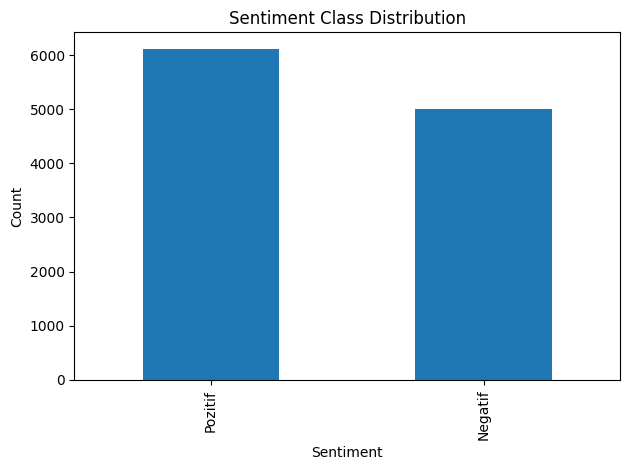

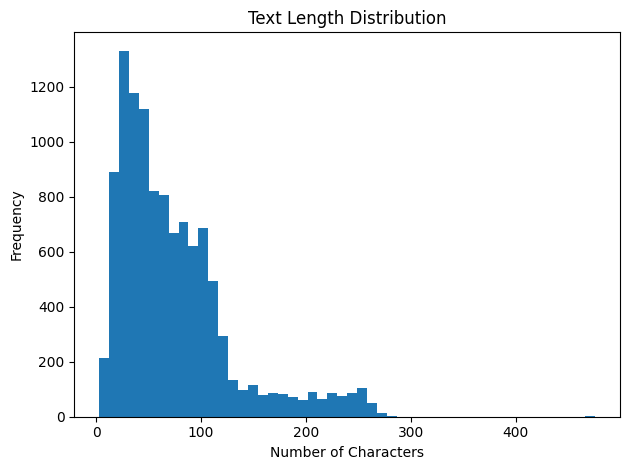

count    11117.000000
mean        73.673653
std         54.276949
min          3.000000
25%         34.000000
50%         60.000000
75%         97.000000
max        476.000000
Name: text_length, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

# Sınıf dağılımı
plt.figure()
df["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Metin uzunluğu
df["text_length"] = df["text"].str.len()

plt.figure()
plt.hist(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(df["text_length"].describe())

In [ ]:
from sklearn.model_selection import train_test_split

X = df["text"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 8893
Test size: 2224


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [ ]:
lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),   # unigram + bigram
        min_df=2,
        max_df=0.95
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Macro F1:", f1_score(y_test, y_pred_lr, average="macro"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8633093525179856
Logistic Regression Macro F1: 0.8604929100843526

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.88      0.80      0.84      1001
     Pozitif       0.85      0.91      0.88      1223

    accuracy                           0.86      2224
   macro avg       0.87      0.86      0.86      2224
weighted avg       0.86      0.86      0.86      2224



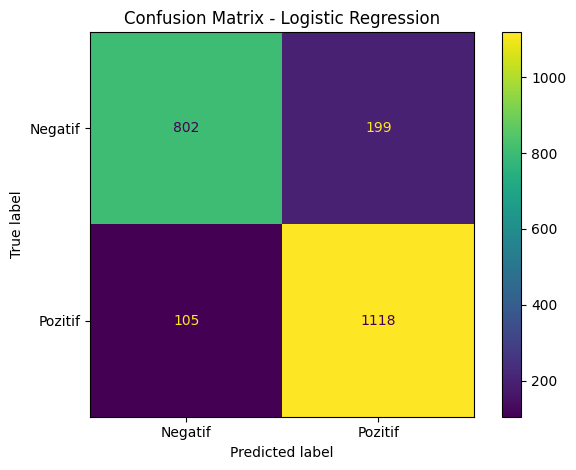

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

labels = np.unique(y_test)

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=labels
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("clf", LinearSVC())
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Macro F1:", f1_score(y_test, y_pred_svm, average="macro"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8610611510791367
SVM Macro F1: 0.8582900552742525

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.88      0.80      0.84      1001
     Pozitif       0.85      0.91      0.88      1223

    accuracy                           0.86      2224
   macro avg       0.86      0.86      0.86      2224
weighted avg       0.86      0.86      0.86      2224



In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression (TF-IDF)",
        "Linear SVM (TF-IDF)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_lr, average="macro"),
        f1_score(y_test, y_pred_svm, average="macro")
    ]
})

results

,Model,Accuracy,Macro F1
0,Logistic Regression (TF-IDF),0.863309,0.860493
1,Linear SVM (TF-IDF),0.861061,0.858290


In [ ]:
print(df.columns.tolist())

['text', 'label', 'text_length']
